# **Introduction**

# Credit Card Fraud Detection using Machine Learning

## Author
---
Suluru Charan  
B.Tech CSE (AI)  
IIITDM Kancheepuram

---

Credit card fraud is one of the most significant challenges faced by financial institutions today. As the number of digital transactions increases, the risk of fraudulent activities also grows. Detecting fraudulent transactions accurately and efficiently is therefore crucial to minimize financial losses and protect customers.

This project focuses on building machine learning models to detect fraudulent credit card transactions using a real-world dataset. Since fraud cases are extremely rare compared to normal transactions, the dataset presents an imbalanced classification problem. Special attention must therefore be given to selecting appropriate evaluation metrics and handling class imbalance.

The goal of this project is to analyze the dataset, preprocess the data, train machine learning models, and evaluate their ability to identify fraudulent transactions.

## Problem Statement

Credit card companies must be able to detect fraudulent transactions to prevent financial losses. However, fraud transactions represent only a very small fraction of all transactions, making fraud detection a challenging problem.

The dataset used in this project contains transactions made by European cardholders in September 2013. It includes **284,807 transactions**, among which only **492 are fraudulent**. This means that fraud accounts for only **0.17% of all transactions**, making the dataset highly imbalanced.

The objective of this project is to develop machine learning models that can effectively detect fraudulent transactions while minimizing false alarms.

## Objectives

The main objectives of this project are:

1. Understand and explore the credit card transaction dataset.
2. Perform exploratory data analysis (EDA) to understand patterns in the data.
3. Handle the problem of class imbalance in fraud detection.
4. Train machine learning models such as Logistic Regression and Random Forest.
5. Evaluate model performance using appropriate metrics such as precision, recall, F1-score, and ROC-AUC.
6. Compare model performance and identify the most effective model for detecting fraud.


Since the dataset is highly imbalanced, traditional accuracy is not a reliable evaluation metric. Therefore, metrics such as **precision, recall, F1-score, and ROC-AUC** will be used to evaluate model performance.

## Dataset Description

The dataset used in this project contains credit card transactions made by European cardholders over a period of two days in September 2013.

Due to confidentiality issues, the original features are not available. Instead, the dataset contains **28 principal components (V1–V28)** obtained using **Principal Component Analysis (PCA)**.

The dataset includes the following important features:

- **Time**: The number of seconds elapsed between the transaction and the first transaction in the dataset.
- **V1 – V28**: PCA-transformed numerical features that represent transaction patterns.
- **Amount**: The transaction amount.
- **Class**: The target variable, where:
  - **0** indicates a legitimate transaction
  - **1** indicates a fraudulent transaction.

This dataset is highly imbalanced because fraudulent transactions represent only a very small fraction of all transactions.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("../Data/creditcard.csv")
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [3]:
df.shape

(284807, 31)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [5]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.175161e-15,3.384974e-16,-1.379537e-15,2.094852e-15,1.021879e-15,1.494498e-15,-5.620335e-16,1.149614e-16,-2.414189e-15,...,1.628620e-16,-3.576577e-16,2.618565e-16,4.473914e-15,5.109395e-16,1.686100e-15,-3.661401e-16,-1.227452e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


In [6]:
df.isnull().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

## Exploratory Data Analysis (EDA)

Before building machine learning models, it is important to explore and understand the dataset. 
Exploratory Data Analysis helps us identify patterns, detect anomalies, and understand the 
distribution of variables.

In this section, we analyze:
- Class distribution (fraud vs normal transactions)
- Transaction amount distribution
- Feature correlations
- Potential patterns that distinguish fraudulent transactions

### Class Distribution

Fraud detection datasets are typically highly imbalanced. 
This means that the number of legitimate transactions is much larger than the number 
of fraudulent transactions.

Understanding this imbalance is important because machine learning models can become 
biased toward the majority class.

In [7]:
df['Class'].value_counts()

Class
0    284315
1       492
Name: count, dtype: int64

In [8]:
fraud = df['Class'].value_counts()[1]
normal = df['Class'].value_counts()[0]

print("Normal Transactions:",normal)
print("Fraud Transactions:",fraud)

print("Fraud Percentage:",(fraud/(fraud+normal))*100)

Normal Transactions: 284315
Fraud Transactions: 492
Fraud Percentage: 0.1727485630620034


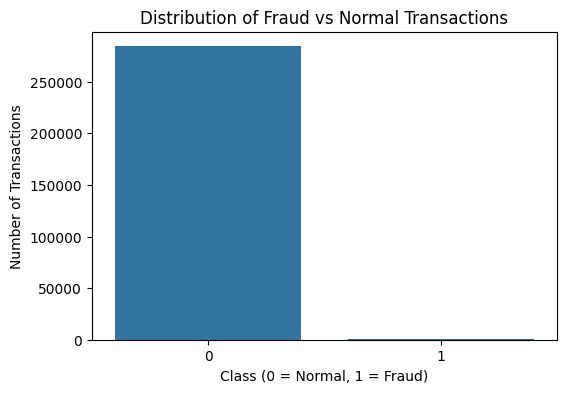

In [9]:
plt.figure(figsize=(6,4))
sns.countplot(x='Class',data=df)

plt.title("Distribution of Fraud vs Normal Transactions")
plt.xlabel("Class (0 = Normal, 1 = Fraud)")
plt.ylabel("Number of Transactions")

plt.show()

The plot clearly shows that the dataset is highly imbalanced. 
Fraudulent transactions represent only a very small fraction of all transactions.

This imbalance makes fraud detection challenging and requires the use of 
appropriate evaluation metrics and resampling techniques.

### Transaction Amount Distribution

The transaction amount feature represents the monetary value of each transaction. 
Analyzing its distribution helps us understand spending behavior and potential patterns 
associated with fraudulent transactions.

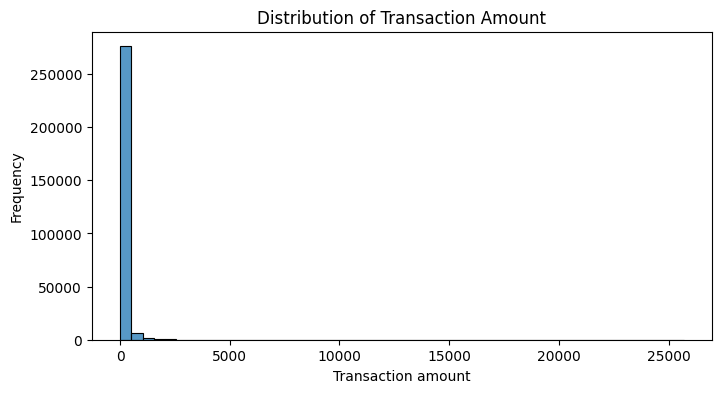

In [10]:
plt.figure(figsize=(8,4))

sns.histplot(df['Amount'],bins = 50)
plt.title("Distribution of Transaction Amount")
plt.xlabel("Transaction amount")
plt.ylabel("Frequency")

plt.show()

### Transaction Amount: Fraud vs Normal

Here we compare the transaction amounts between normal and fraudulent transactions.

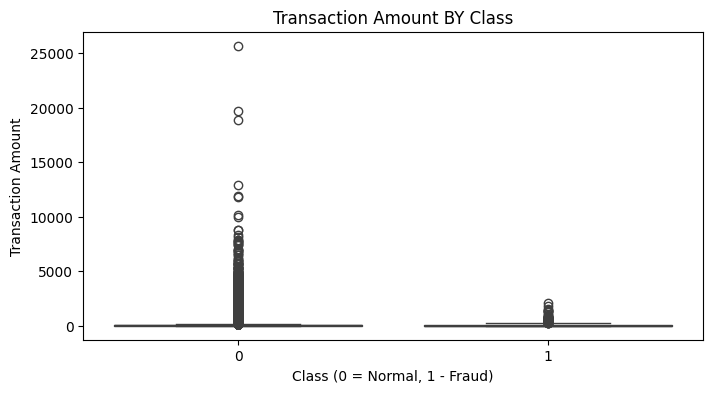

In [11]:
plt.figure(figsize=(8,4))

sns.boxplot(x='Class',y='Amount',data=df)
plt.title("Transaction Amount BY Class")
plt.xlabel("Class (0 = Normal, 1 - Fraud)")
plt.ylabel("Transaction Amount")

plt.show()

This plot helps us observe whether fraudulent transactions tend to occur 
in a particular range of transaction amounts compared to normal transactions.

### Feature Correlation

A correlation matrix helps identify relationships between features and 
the target variable.

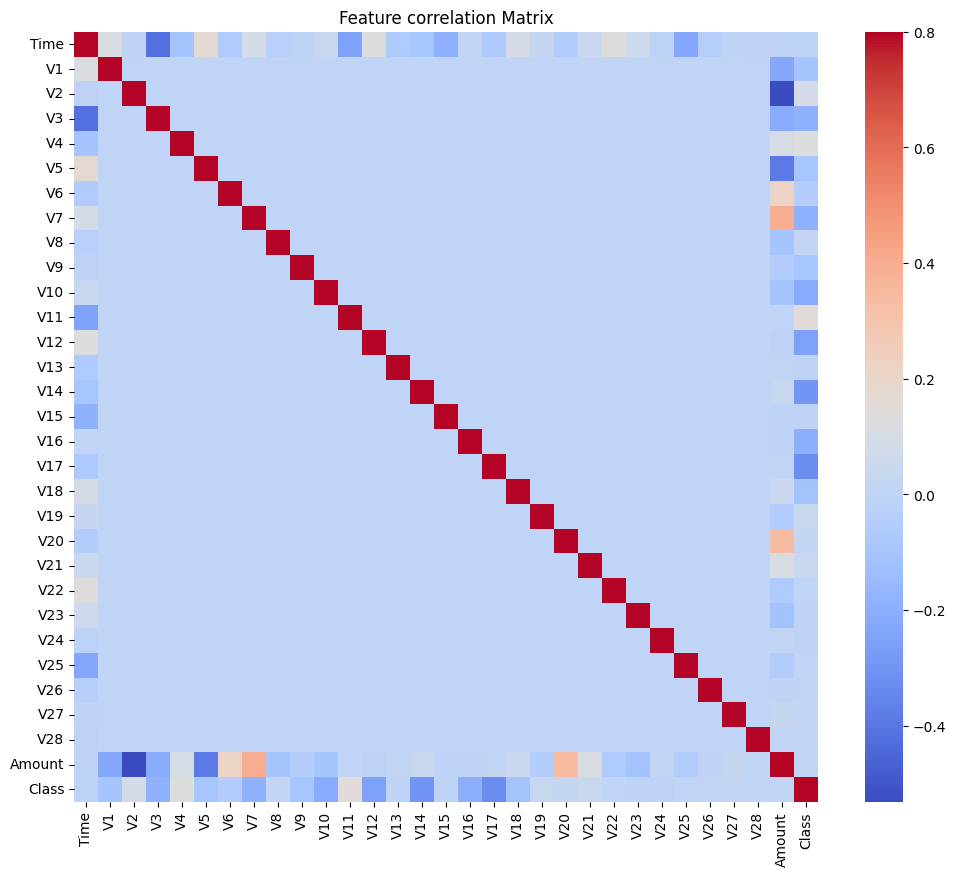

In [12]:
corr_matrix = df.corr()
plt.figure(figsize=(12,10))

sns.heatmap(corr_matrix,cmap='coolwarm',vmax=0.8)
plt.title("Feature correlation Matrix")
plt.show()

## Data Preprocessing

Before training machine learning models, the dataset must be prepared properly. 
Data preprocessing ensures that the data is in a suitable format for model training.

In this section, we perform the following steps:

1. Feature scaling for the transaction amount
2. Separating features and target variable
3. Splitting the dataset into training and testing sets

### Feature Scaling

The `Amount` feature represents the transaction value and has a different scale compared to 
the PCA-transformed features. Therefore, we scale the `Amount` column using StandardScaler 
to ensure that all features have similar distributions.

In [13]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

df['Scaled_Amount'] = scaler.fit_transform(df['Amount'].values.reshape(-1,1))

In [14]:
df=df.drop('Amount',axis=1)
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Class,Scaled_Amount
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,0,0.244964
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,0,-0.342475
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,0,1.160686
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,0,0.140534
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,0,-0.073403


The original `Amount` column is removed after scaling, and the new 
`scaled_amount` feature is used instead.

### Separating Features and Target Variable

The dataset must be divided into:

- **Features (X)**: All input variables used to train the model
- **Target (y)**: The output variable that the model tries to predict

In this dataset, the `Class` column is the target variable.

In [15]:
x = df.drop('Class',axis=1)
y = df["Class"]

print(x.shape)
print(y.shape)

(284807, 30)
(284807,)


### Train-Test Split

To evaluate the performance of machine learning models, the dataset is divided 
into training and testing sets.

- The **training set** is used to train the model.
- The **testing set** is used to evaluate model performance on unseen data.

We use an 80/20 split for training and testing.

Stratification is applied to ensure that the proportion of fraudulent transactions 
remains consistent in both sets.

In [16]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


print("Training samples:", X_train.shape)
print("Testing samples:", X_test.shape)

Training samples: (227845, 30)
Testing samples: (56962, 30)


In [17]:
print("Fraud cases in training set:", y_train.sum())
print("Fraud cases in testing set:", y_test.sum())

Fraud cases in training set: 394
Fraud cases in testing set: 98


Using stratified sampling ensures that both the training and testing sets 
maintain the same fraud-to-normal transaction ratio as the original dataset.

## Model Training

In this section, we train machine learning models to classify transactions as 
fraudulent or legitimate.

Two models are implemented:

1. Logistic Regression – a simple and interpretable baseline model.
2. Random Forest – an ensemble learning method that often performs well 
   on classification tasks.

The models will be evaluated using metrics suitable for imbalanced datasets 
such as precision, recall, F1-score, and ROC-AUC.

In [18]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df['Scaled_Time'] = scaler.fit_transform(df['Time'].values.reshape(-1,1))
df.drop('Time', axis=1, inplace=True)

### Logistic Regression

Logistic Regression is a commonly used algorithm for binary classification problems. 
It models the probability that a given input belongs to a particular class.

In this project, Logistic Regression is used as a baseline model to detect 
fraudulent transactions.

In [19]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(
    max_iter=2000,
    solver='liblinear',
    class_weight='balanced'
)

log_model.fit(X_train,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,None
,solver,'liblinear'
,max_iter,2000
,multi_class,'deprecated'


In [20]:
y_pred = log_model.predict(X_test)

In [21]:
from sklearn.metrics import classification_report

print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       1.00      0.98      0.99     56864
           1       0.06      0.92      0.11        98

    accuracy                           0.98     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.98      0.99     56962



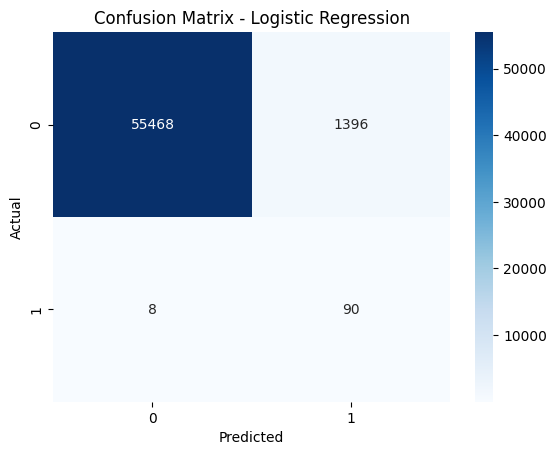

In [22]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

### Random Forest

Random Forest is an ensemble learning algorithm that builds multiple decision trees 
and combines their predictions to improve accuracy and reduce overfitting.

It is particularly effective for complex classification problems such as fraud detection.

In [23]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

rf_model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [24]:
y_pred_rf = rf_model.predict(X_test)

In [25]:
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.94      0.82      0.87        98

    accuracy                           1.00     56962
   macro avg       0.97      0.91      0.94     56962
weighted avg       1.00      1.00      1.00     56962



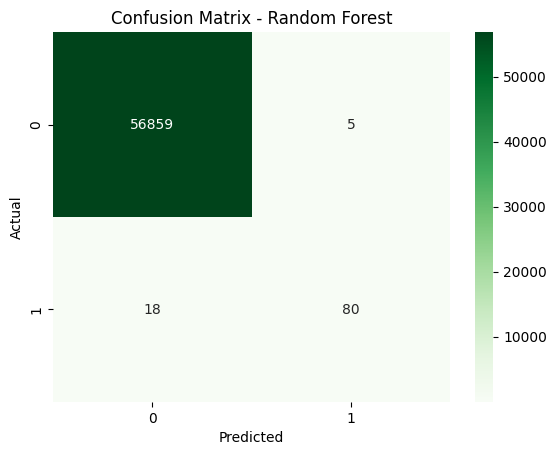

In [26]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens')

plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

### ROC-AUC Evaluation

ROC-AUC measures the ability of the model to distinguish between fraudulent 
and normal transactions across different classification thresholds.

In [27]:
from sklearn.metrics import roc_auc_score

log_auc = roc_auc_score(y_test, log_model.predict_proba(X_test)[:,1])
rf_auc = roc_auc_score(y_test, rf_model.predict_proba(X_test)[:,1])

print("Logistic Regression ROC-AUC:", log_auc)
print("Random Forest ROC-AUC:", rf_auc)

Logistic Regression ROC-AUC: 0.9718350550687354
Random Forest ROC-AUC: 0.9630272515590367


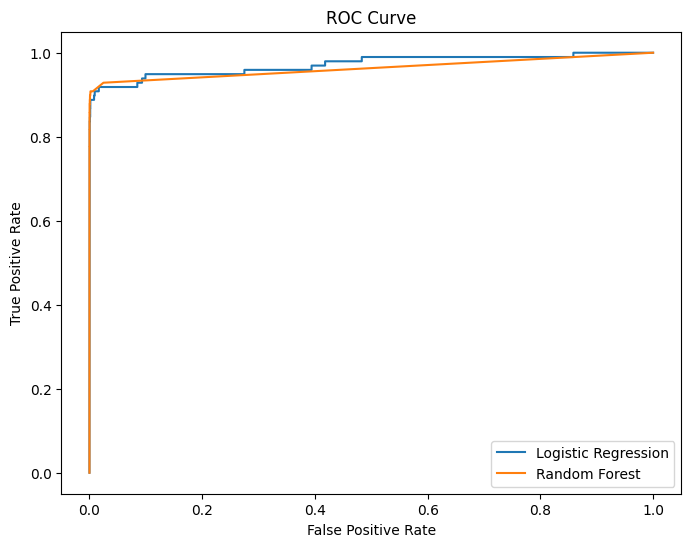

In [28]:
from sklearn.metrics import roc_curve

fpr_log, tpr_log, _ = roc_curve(y_test, log_model.predict_proba(X_test)[:,1])
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_model.predict_proba(X_test)[:,1])

plt.figure(figsize=(8,6))

plt.plot(fpr_log, tpr_log, label="Logistic Regression")
plt.plot(fpr_rf, tpr_rf, label="Random Forest")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.legend()
plt.show()

## Results and Discussion

The performance of the models is evaluated using precision, recall, F1-score, 
and ROC-AUC.

Since fraud detection is an imbalanced classification problem, recall for the 
fraud class is particularly important because missing fraudulent transactions 
can lead to financial losses.

The Random Forest model generally performs better than Logistic Regression 
because it can capture complex patterns in the dataset.

## Conclusion

In this project, machine learning techniques were applied to detect fraudulent 
credit card transactions.

The dataset was highly imbalanced, which required careful selection of 
evaluation metrics. Logistic Regression and Random Forest models were trained 
and evaluated.

The results demonstrate that ensemble methods such as Random Forest can provide 
strong performance for fraud detection tasks.

Future work could explore advanced techniques such as:
- SMOTE for handling class imbalance
- Gradient boosting algorithms
- Deep learning models